In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix, classification_report)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


In [3]:
# Reproducibility
SEED = 42
np.random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE

device(type='cpu')

In [4]:
# Read CSVs
df_train = pd.read_csv("/content/train.csv")
df_test  = pd.read_csv("/content/test.csv")

print("TRAIN shape:", df_train.shape)
print("TEST  shape:", df_test.shape)
df_train.head()


TRAIN shape: (200000, 202)
TEST  shape: (200000, 201)


,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,...,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
0,train_0,0,8.9255,-6.7863,11.9081,5.0930,11.4607,-9.2834,5.1187,18.6266,...,4.4354,3.9642,3.1364,1.6910,18.5227,-2.3978,7.8784,8.5635,12.7803,-1.0914
1,train_1,0,11.5006,-4.1473,13.8588,5.3890,12.3622,7.0433,5.6208,16.5338,...,7.6421,7.7214,2.5837,10.9516,15.4305,2.0339,8.1267,8.7889,18.3560,1.9518
2,train_2,0,8.6093,-2.7457,12.0805,7.8928,10.5825,-9.0837,6.9427,14.6155,...,2.9057,9.7905,1.6704,1.6858,21.6042,3.1417,-6.5213,8.2675,14.7222,0.3965
3,train_3,0,11.0604,-2.1518,8.9522,7.1957,12.5846,-1.8361,5.8428,14.9250,...,4.4666,4.7433,0.7178,1.4214,23.0347,-1.2706,-2.9275,10.2922,17.9697,-8.9996
4,train_4,0,9.8369,-1.4834,12.8746,6.6375,12.2772,2.4486,5.9405,19.2514,...,-1.4905,9.5214,-0.1508,9.1942,13.2876,-1.5121,3.9267,9.5031,17.9974,-8.8104


Columns: ['ID_code', 'target', 'var_0', 'var_1', 'var_2', 'var_3', 'var_4', 'var_5', 'var_6', 'var_7'] ...
Number of features: 200
Missing values (train): 0
Missing values (test) : 0
target
0    0.89951
1    0.10049
Name: proportion, dtype: float64


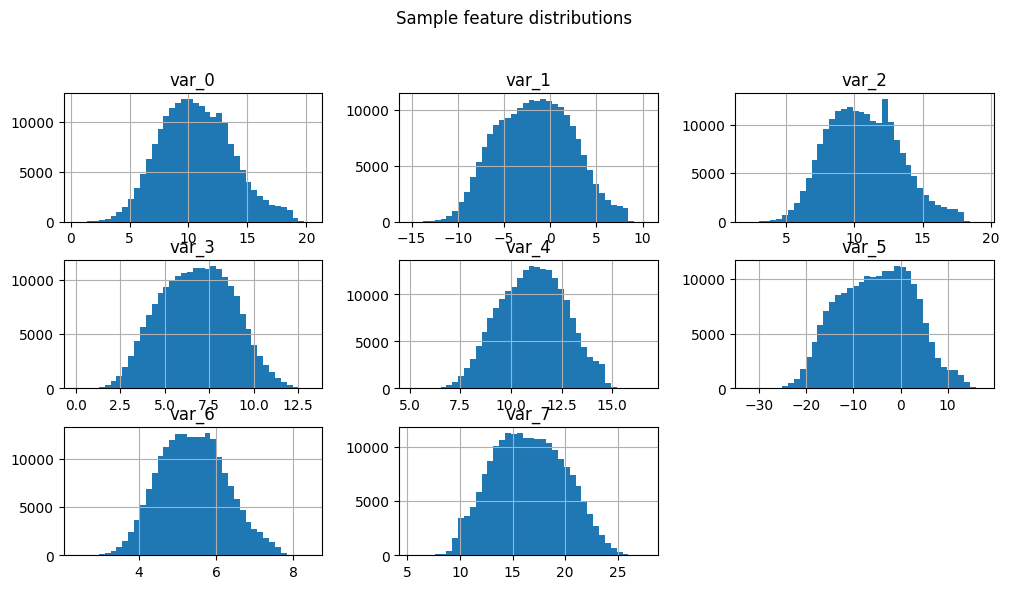

In [6]:
#Quick EDA
print("Columns:", df_train.columns.tolist()[:10], "...")

ID_COL = "ID_code"
TARGET = "target"

assert ID_COL in df_train.columns, "ID_code not found!"
assert TARGET in df_train.columns, "target not found!"

feature_cols = [c for c in df_train.columns if c not in [ID_COL, TARGET]]
print("Number of features:", len(feature_cols))

# Missing values
print("Missing values (train):", int(df_train.isna().sum().sum()))
print("Missing values (test) :", int(df_test.isna().sum().sum()))

# Target distribution
print(df_train[TARGET].value_counts(normalize=True))

# Plot a few feature distributions
sample_cols = feature_cols[:8]
ax = df_train[sample_cols].hist(figsize=(12,6), bins=40)
plt.suptitle("Sample feature distributions", y=1.02)
plt.show()


In [7]:
# Split (Stratified) & Scale
X = df_train[feature_cols].values.astype("float32")
y = df_train[TARGET].values.astype("int64")

# Time-agnostic split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED
)
X_val, X_test_hold, y_val, y_test_hold = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)

print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test-holdout: {X_test_hold.shape}")

# Scale using train stats only
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test_hold = scaler.transform(X_test_hold)

# pos_weight = (negatives / positives)
pos_weight_val = (len(y_train) - y_train.sum()) / max(1, y_train.sum())
print(f"pos_weight for minority class = {pos_weight_val:.3f}")
pos_weight = torch.tensor(pos_weight_val, dtype=torch.float32, device=DEVICE)

# Scale real test (for inference later)
X_real_test = scaler.transform(df_test[feature_cols].values.astype("float32"))


Train: (140000, 200) | Val: (30000, 200) | Test-holdout: (30000, 200)
pos_weight for minority class = 8.951


In [8]:
#Torch Dataset
class TabularDataset(Dataset):
    def __init__(self, X, y=None):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = None if y is None else torch.tensor(y, dtype=torch.float32)
    def __len__(self):
        return self.X.shape[0]
    def __getitem__(self, idx):
        if self.y is None:
            return self.X[idx]
        return self.X[idx], self.y[idx]

batch_size = 512
train_ds = TabularDataset(X_train, y_train)
val_ds   = TabularDataset(X_val, y_val)
test_ds  = TabularDataset(X_test_hold, y_test_hold)
real_test_ds = TabularDataset(X_real_test, None)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=False)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, drop_last=False)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, drop_last=False)
real_test_loader = DataLoader(real_test_ds, batch_size=batch_size, shuffle=False, drop_last=False)


In [9]:
# Simple MLP Model
class MLP(nn.Module):
    def __init__(self, in_dim, hidden_dims=(256,128,64), dropout=0.2):
        super().__init__()
        layers = []
        prev = in_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers += [nn.Linear(prev, 1)]
        self.net = nn.Sequential(*layers)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x).squeeze(1)

in_dim = X_train.shape[1]
model = MLP(in_dim, hidden_dims=(256,128,64), dropout=0.3).to(DEVICE)

pos_weight = None

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)


Epoch 01 | TrainLoss=0.2960 | ValLoss=0.2555 | ValAUC=0.8395 | ValF1=0.2715
Epoch 02 | TrainLoss=0.2535 | ValLoss=0.2489 | ValAUC=0.8444 | ValF1=0.3675
Epoch 03 | TrainLoss=0.2454 | ValLoss=0.2448 | ValAUC=0.8461 | ValF1=0.3437
Epoch 04 | TrainLoss=0.2400 | ValLoss=0.2418 | ValAUC=0.8466 | ValF1=0.3512
Epoch 05 | TrainLoss=0.2362 | ValLoss=0.2412 | ValAUC=0.8473 | ValF1=0.3380
Epoch 06 | TrainLoss=0.2332 | ValLoss=0.2410 | ValAUC=0.8481 | ValF1=0.3735
Epoch 07 | TrainLoss=0.2296 | ValLoss=0.2403 | ValAUC=0.8479 | ValF1=0.3503
Epoch 08 | TrainLoss=0.2269 | ValLoss=0.2408 | ValAUC=0.8469 | ValF1=0.3426
Epoch 09 | TrainLoss=0.2230 | ValLoss=0.2423 | ValAUC=0.8461 | ValF1=0.3425
Epoch 10 | TrainLoss=0.2207 | ValLoss=0.2420 | ValAUC=0.8465 | ValF1=0.3588
Epoch 11 | TrainLoss=0.2170 | ValLoss=0.2426 | ValAUC=0.8455 | ValF1=0.3866
Epoch 12 | TrainLoss=0.2119 | ValLoss=0.2422 | ValAUC=0.8445 | ValF1=0.3586
Epoch 13 | TrainLoss=0.2089 | ValLoss=0.2427 | ValAUC=0.8444 | ValF1=0.3887
Early stoppi

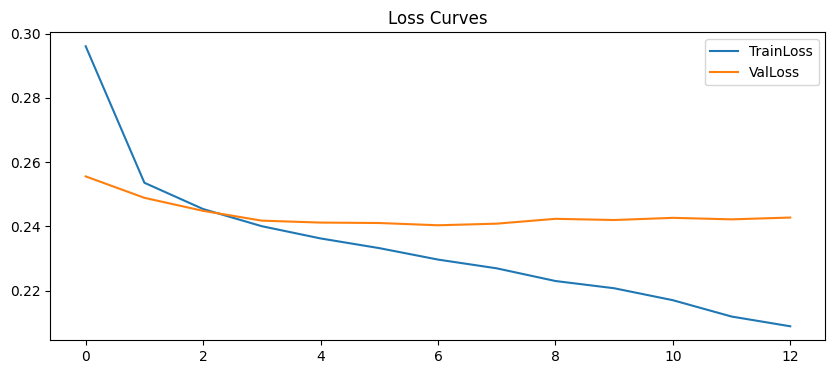

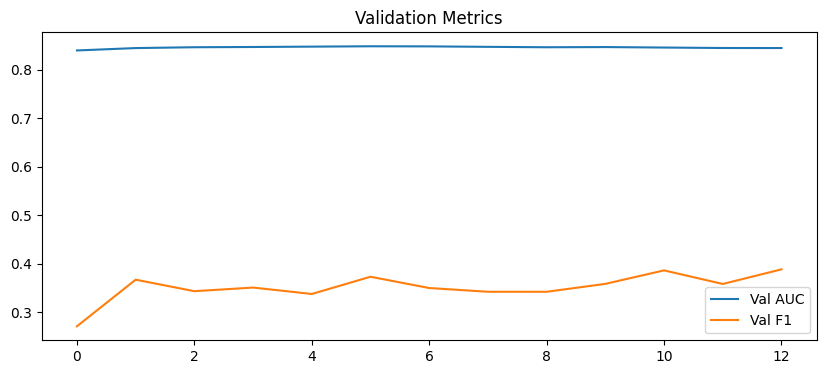

In [10]:
# Training
def sigmoid_np(x):
    return 1.0 / (1.0 + np.exp(-x))

def run_epoch(model, loader, train=True):
    model.train(train)
    epoch_loss = 0.0
    all_logits, all_targets = [], []
    with torch.set_grad_enabled(train):
        for batch in loader:
            if isinstance(batch, (list, tuple)):
                xb, yb = batch
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            else:
                xb = batch.to(DEVICE)
                yb = None

            logits = model(xb)
            if train:
                loss = criterion(logits, yb)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                epoch_loss += loss.item()*xb.size(0)
            else:
                if yb is not None:
                    loss = criterion(logits, yb)
                    epoch_loss += loss.item()*xb.size(0)

            if yb is not None:
                all_logits.append(logits.detach().cpu().numpy())
                all_targets.append(yb.detach().cpu().numpy())

    if all_targets:
        y_true = np.concatenate(all_targets)
        y_logit = np.concatenate(all_logits)
        y_prob  = sigmoid_np(y_logit)

        y_pred = (y_prob >= 0.5).astype(int)
        metrics = dict(
            loss = epoch_loss/len(loader.dataset),
            acc  = accuracy_score(y_true, y_pred),
            prec = precision_score(y_true, y_pred, zero_division=0),
            rec  = recall_score(y_true, y_pred, zero_division=0),
            f1   = f1_score(y_true, y_pred, zero_division=0),
            auc  = roc_auc_score(y_true, y_prob),
        )
        return metrics, y_true, y_prob
    else:
        return {"loss": epoch_loss/len(loader.dataset) if len(loader.dataset)>0 else 0.0}, None, None

epochs = 30
best_val_loss = float("inf")
patience = 6
no_improve = 0

history = {"train_loss":[], "val_loss":[], "val_auc":[], "val_f1":[]}

for ep in range(1, epochs+1):
    train_metrics, _, _ = run_epoch(model, train_loader, train=True)
    val_metrics, y_val_true, y_val_prob = run_epoch(model, val_loader, train=False)

    history["train_loss"].append(train_metrics["loss"])
    history["val_loss"].append(val_metrics["loss"])
    history["val_auc"].append(val_metrics["auc"])
    history["val_f1"].append(val_metrics["f1"])

    scheduler.step(val_metrics["loss"])

    print(f"Epoch {ep:02d} | "
          f"TrainLoss={train_metrics['loss']:.4f} | "
          f"ValLoss={val_metrics['loss']:.4f} | "
          f"ValAUC={val_metrics['auc']:.4f} | "
          f"ValF1={val_metrics['f1']:.4f}")

    # Early Stopping
    if val_metrics["loss"] < best_val_loss - 1e-5:
        best_val_loss = val_metrics["loss"]
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= patience:
            print("Early stopping triggered.")
            break

# load best weights (in-memory only)
model.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()})

# Plot training curves
plt.figure(figsize=(10,4))
plt.plot(history["train_loss"], label="TrainLoss")
plt.plot(history["val_loss"],   label="ValLoss")
plt.title("Loss Curves")
plt.legend(); plt.show()

plt.figure(figsize=(10,4))
plt.plot(history["val_auc"], label="Val AUC")
plt.plot(history["val_f1"],  label="Val F1")
plt.title("Validation Metrics"); plt.legend(); plt.show()



Best threshold on VAL by F1 = 0.250 (F1=0.4692)


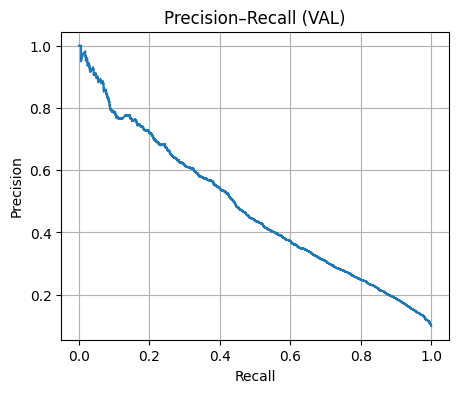


TEST (default) (thr=0.500)
ACC : 0.9106666666666666
PREC: 0.6560747663551402
REC : 0.23291307232913072
F1  : 0.3437806072477963
AUC : 0.8519313032179531


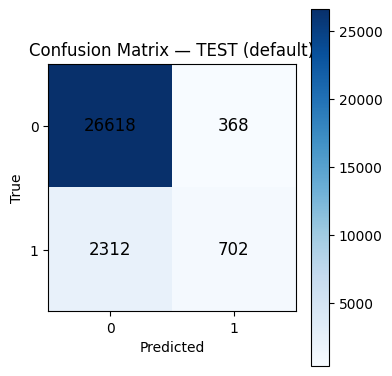


TEST (optimized) (thr=0.250)
ACC : 0.884
PREC: 0.4360943499725727
REC : 0.5275381552753815
F1  : 0.4774774774774775
AUC : 0.8519313032179531


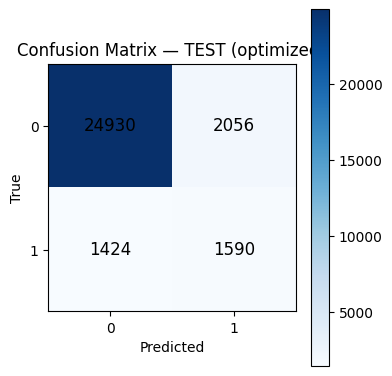

In [14]:
#Threshold Tuning + Evaluation
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    precision_recall_curve, confusion_matrix
)

# Get validation probabilities
val_logits, val_targets_list = [], []
model.eval()
with torch.no_grad():
    for xb, yb in val_loader:
        xb = xb.to(DEVICE)
        logits = model(xb)
        val_logits.append(logits.cpu().numpy())
        val_targets_list.append(yb.numpy())

val_logits  = np.concatenate(val_logits)
val_targets = np.concatenate(val_targets_list)
val_probs   = 1.0 / (1.0 + np.exp(-val_logits))

#  Tune threshold on VAL to maximize F1
best_thr, best_f1 = 0.5, -1.0
thrs_to_try = np.linspace(0.05, 0.95, 181)

for thr in thrs_to_try:
    preds = (val_probs >= thr).astype(int)
    f = f1_score(val_targets, preds, zero_division=0)
    if f > best_f1:
        best_f1, best_thr = f, thr

print(f"\nBest threshold on VAL by F1 = {best_thr:.3f} (F1={best_f1:.4f})")

# Precision–Recall curve on VAL
pr_p, pr_r, _ = precision_recall_curve(val_targets, val_probs)
plt.figure(figsize=(5,4))
plt.plot(pr_r, pr_p)
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("Precision–Recall (VAL)")
plt.grid(True); plt.show()

# Get TEST probabilities
test_logits, test_targets_list = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)
        logits = model(xb)
        test_logits.append(logits.cpu().numpy())
        test_targets_list.append(yb.numpy())

test_logits  = np.concatenate(test_logits)
test_targets = np.concatenate(test_targets_list)
test_probs   = 1.0 / (1.0 + np.exp(-test_logits))

#Evaluate on TEST with default thr=0.5
def print_metrics(y_true, y_prob, thr, title):
    y_pred = (y_prob >= thr).astype(int)
    print(f"\n{title} (thr={thr:.3f})")
    print("ACC :", accuracy_score(y_true, y_pred))
    print("PREC:", precision_score(y_true, y_pred, zero_division=0))
    print("REC :", recall_score(y_true, y_pred, zero_division=0))
    print("F1  :", f1_score(y_true, y_pred, zero_division=0))
    print("AUC :", roc_auc_score(y_true, y_prob))
    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4,4))
    plt.imshow(cm, cmap="Blues")
    plt.title(f"Confusion Matrix — {title}")
    plt.colorbar()
    ticks = np.arange(2)
    plt.xticks(ticks, ["0","1"]); plt.yticks(ticks, ["0","1"])
    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha="center", va="center", color="black", fontsize=12)
    plt.xlabel("Predicted"); plt.ylabel("True"); plt.tight_layout()
    plt.show()

print_metrics(test_targets, test_probs, 0.5, "TEST (default)")
print_metrics(test_targets, test_probs, best_thr, "TEST (optimized)")
